In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load raw data
df = pd.read_csv('Titanic_EDA.csv')

In [4]:
# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1, errors='ignore')

# (Optional but good) Drop rows where Embarked might still be NaN if mode failed
df = df.dropna(subset=['Embarked'])

print("Data shape after cleaning:", df.shape)

Data shape after cleaning: (891, 11)


In [5]:

y = df['Survived']

# Features (everything except Survived, PassengerId, Name, Ticket - these are useless for prediction)
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

print("Features:", X.columns.tolist())

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [6]:
# Identify categorical columns
categorical_cols = ['Sex', 'Embarked']

# One-hot encode them
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.head())

   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 712 rows
Test set size: 179 rows


In [8]:

numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']

scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [9]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Model Accuracy: 0.8101 (81.01%)


Confusion Matrix:
[[90 15]
 [19 55]]


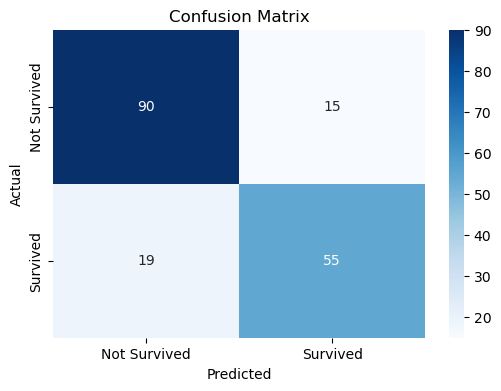


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize it nicely
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

 Interpreting the Confusion Matrix

The confusion matrix shows the breakdown of my model's predictions vs. the actual outcomes:

True Negatives (Top-Left): Passengers who actually did not survive and my model correctly predicted as not survived.
False Positives (Top-Right): Passengers who actually did not survive but my model incorrectly predicted as survived (a "false alarm").
False Negatives (Bottom-Left): Passengers who actually survived but my model incorrectly predicted as not survived (a "missed" survival).
True Positives (Bottom-Right): Passengers who actually survived and my model correctly predicted as survived.

The accuracy score alone isn't enough — the confusion matrix shows where my model makes mistakes. For the Titanic, it's more critical to minimize **False Negatives** (missing actual survivors) if we wanted to save lives, but for this exercise, we just track overall correct predictions.